In [1]:
# Transformers example -> Reverseing sequence of numbers


In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer

from sbi.analysis import pairplot
import numpy as np

jax.devices()

I0000 00:00:1698480691.382595  168191 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-10-28 10:11:36.537926: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [3]:
jax.devices("cpu")

[CpuDevice(id=0)]

In [4]:
jax.devices("gpu")

[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [5]:
ts = jnp.linspace(0, 3, 100)

def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey



In [6]:
num_timeponts = 48
time_start = 0
time_end = 10
ts_dense = jnp.linspace(time_start, time_end, 100)
def generate_data(key, n):

    key1, key2, key3, key4, key5, key6, key_t = jrandom.split(key, 7)

    theta1 = jax.nn.sigmoid(jrandom.normal(key1, (n,1)))*2 + 1.
    theta2 = jax.nn.sigmoid(jrandom.normal(key2, (n,1)))*2 + 1.
    theta3 = jax.nn.sigmoid(jrandom.normal(key3, (n,1)))*2 + 1.
    theta4 = jax.nn.sigmoid(jrandom.normal(key4, (n,1)))*2 + 1.
    
    # Random time points 
    ts = jrandom.uniform(key_t, (n , num_timeponts), minval=time_start, maxval=time_end)
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    predator = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, predator)
    prey = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, prey)

    predator = predator + jrandom.normal(key5, predator.shape) * 0.001
    prey = prey + jrandom.normal(key6, prey.shape) * 0.001

    node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
    node_metadata = jnp.concatenate([jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),ts, ts], axis=1)
    full_data = jnp.concatenate([theta1, theta2, theta3, theta4, predator, prey], axis=1).reshape((n, -1, 1))
    return full_data, node_ids, node_metadata


data, node_ids, node_metadata = generate_data(jrandom.PRNGKey(1
                                                              ), 2)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

print(T_max)

100


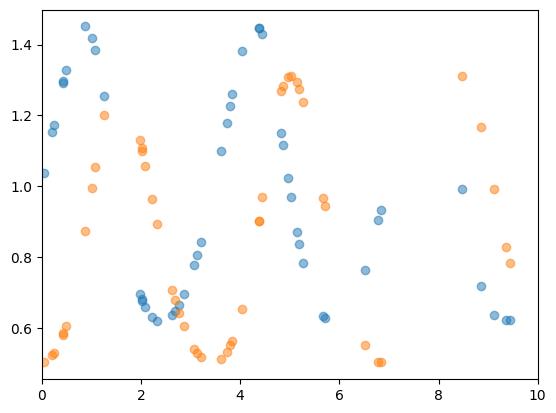

In [7]:
time_evals = node_metadata[:, 4:4+num_timeponts]
predator_trace = data[:, 4:4+num_timeponts]
prey_trace = data[:, 4+num_timeponts:]

for i in range(1):
    plt.scatter(time_evals[i], predator_trace[i], c='C0', alpha=0.5)
    plt.scatter(time_evals[i], prey_trace[i], c='C1', alpha=0.5)
    plt.xlim(0, 10)

In [8]:
key = jrandom.PRNGKey(0)

In [9]:
from probjax.nn.helpers import SinusoidalEmbedding

In [10]:

def model(t, x, node_ids, node_metadata, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions

    dim = 210
    _dim = dim // 3
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim, w_init=hk.initializers.RandomNormal(mean=3., stddev=0.01))
    embedding_metadata = SinusoidalEmbedding(_dim)
    embedding_time = SinusoidalEmbedding(_dim)
    

    # Positional embedding

    model = Transformer(num_heads=8, num_layers=8, attn_size=20, dropout_rate=0.0, widening_factor=4)

    # Embed values adn time
    value_embeddings = embedding_net(x)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape[:-1] + (_dim,))

    # Embed node ids and metadata
    id_embeddings = embedding_id_nets(node_ids)
    metadata_embeddings = embedding_metadata(node_metadata.reshape(-1,x.shape[1],1))
    metadata_embeddings = metadata_embeddings * ~jnp.isnan(metadata_embeddings)
    metadata_embeddings = jnp.broadcast_to(metadata_embeddings, value_embeddings.shape)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    node_emebding = id_embeddings

    # Condition embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(mean=-3.,stddev=0.1))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, x.shape[1],1)
    


    x_encoded = jnp.concatenate([value_embeddings, node_emebding, metadata_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding

    # Encode
    h = model(x_encoded, context=time_embeddings)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [11]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, node_metadata, jnp.zeros_like(node_ids))

In [12]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids,node_metadata, jnp.zeros_like(node_ids))

In [13]:
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [14]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, key, batch_size= 64):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs, node_ids, node_metadata = generate_data(rng_data, batch_size) # n, T_max, 1

 
    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0]*T_max, [1,1,1,1] + [0]*(T_max-4),[0,0,0,0] + [1]*(T_max-4), jrandom.bernoulli(rng_permute_ids, 0.3, shape=(T_max,)).astype(int),jrandom.bernoulli(rng_permute_ids + 1, 0.7, shape=(T_max,)).astype(int)]), shape=(batch_size, ), axis=0)
    condition_mask = condition_mask[..., None]


    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-condition_mask) + batch_xs * condition_mask # Condition on the data

    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, node_ids,node_metadata, condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    # lam = beta(times) 
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times) + 1e-4
    # Loss

    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


# @jax.jit
# def update(params, rng, opt_state):
#     loss, grads = jax.value_and_grad(loss_fn)(params, rng)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return loss, params, opt_state

In [15]:
from functools import partial

@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    grads = jax.lax.pmean(grads, axis_name='num_devices')
    loss = jax.lax.pmean(loss, axis_name='num_devices')
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [16]:
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [17]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [18]:
key = jrandom.PRNGKey(0)
for j in range(25):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

18.462406
14.397457
10.16686
5.922864
4.3560853
3.7924867
3.2328825
2.8356893
2.6838157
2.6550086
2.3221233
2.124926
2.2280598
1.8842045
1.8949057
2.0065897
1.6706457
1.7100952
1.7110863
1.5312971
1.5583136
1.8667637
1.5267487
1.5513272
1.5816876


In [19]:
key = jrandom.PRNGKey(1)
for j in range(25):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

1.4337142
1.4451412
1.5324427
1.4677427
1.4277045
1.3724244
1.3620178
1.3567992
1.3672413
1.4067436
1.56681
1.2187148
1.3637805
1.4600736
1.4919157
1.2279388
1.3710622
1.3396803
1.3632782
1.2050704
1.1492383
1.1611471
1.3811443
1.2737657
1.3772755


In [20]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [21]:
jnp.savez("transformer_based_inference_diffusion_lotka_volterra.npz", params)

In [22]:
from functools import partial

node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(jnp.linspace(time_start + 0.01, time_end , num_timeponts)) + list(jnp.linspace(time_start +0.01, time_end, num_timeponts))) # Time points
condition_mask = jnp.array([0]*T_max, dtype=int)

def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask, node_metadata=node_metadata):
    #t = T - t
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,node_metadata, condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask[:len(node_ids)])
    return f

def diffusion_backward(t,x, node_ids=node_ids,node_metadata=node_metadata,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [23]:
from probjax.utils.sdeint import sdeint

In [24]:

def sample_fn(key, shape, node_ids=node_ids, node_metadata=node_metadata, time_steps=1000, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids=node_ids, node_metadata=node_metadata,condition_mask= condition_mask), lambda t, x: diffusion_backward(t, x, node_ids=node_ids, condition_mask=condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys[:, -1, :]

In [25]:

samples = sample_fn(jrandom.PRNGKey(0), (100, ))

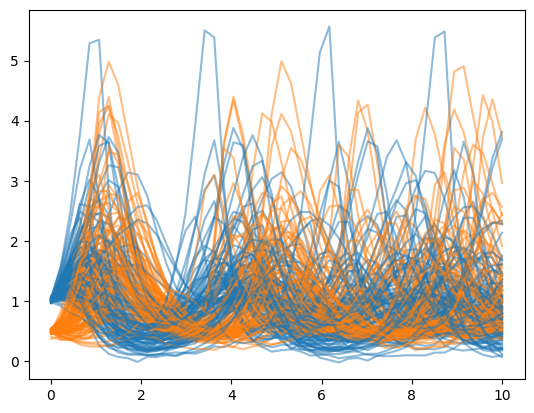

In [26]:
time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]

for i in range(100):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)

In [39]:
condition_mask = jnp.array([1,1,1,1] + [0]*(T_max-4), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + [0]*(T_max-4))


samples = sample_fn(jrandom.PRNGKey(0), (10, ), condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

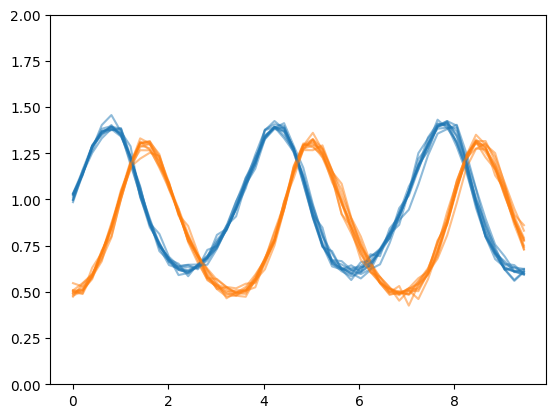

In [40]:
time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]

for i in range(10):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)
    plt.ylim(0,2)

In [ ]:
condition_mask = jnp.array([0,0,0,0] + [1]*(T_max-4), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + samples[0, 4:].tolist())


samples = sample_fn(jrandom.PRNGKey(0), (500, ), condition_mask=condition_mask, condition_value=condition_value, time_steps=1000)

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='theta1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='theta2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='theta3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='theta4'>]],
       dtype=object))

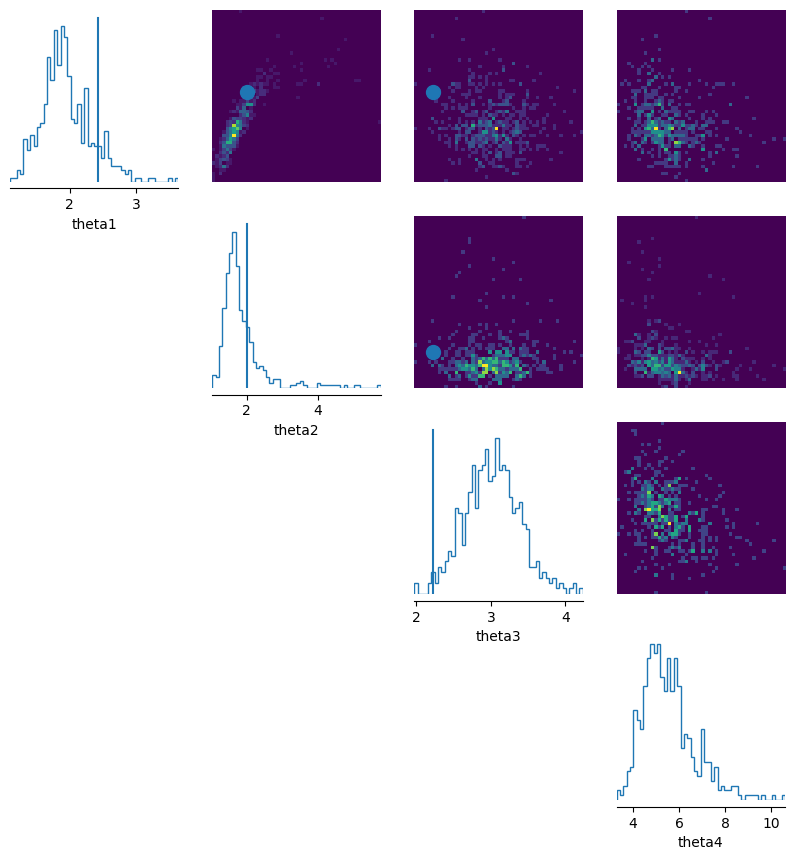

In [36]:
pairplot(np.array(samples[:, :4]), points=data[1, :4, 0], labels=["theta1", "theta2", "theta3", "theta4"])

In [29]:
condition_mask = jnp.array([0,0,0,0] + [0]*(T_max-4), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + [0]*(T_max-4))

condition_mask = condition_mask.at[20].set(1)
condition_value = condition_value.at[20].set(1.5)

condition_mask = condition_mask.at[15].set(1)
condition_value = condition_value.at[15].set(.5)

condition_mask = condition_mask.at[10].set(1)
condition_value = condition_value.at[10].set(1.)


samples = sample_fn(jrandom.PRNGKey(0), (100, ), condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

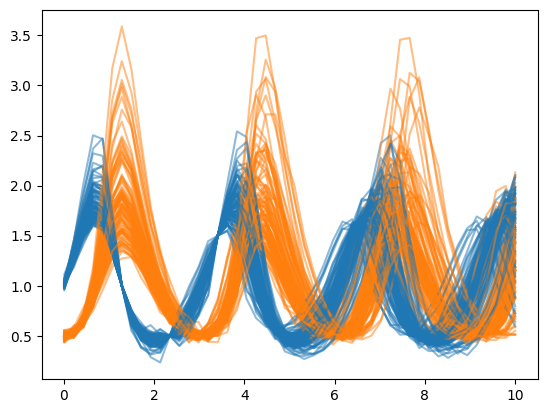

In [30]:
time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]

for i in range(100):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)


In [37]:
num_timeponts2 = 200
t1 = jnp.linspace(time_start + 0.01, time_end + 30, num_timeponts2)
node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts2 + [5] * num_timeponts2)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(t1) + list(t1)) # Time points

condition_mask = jnp.array([1,1,1,1] + [0]*(2*num_timeponts2), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + [0]*(2*num_timeponts2))


samples = sample_fn(jrandom.PRNGKey(1), (10, ), node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

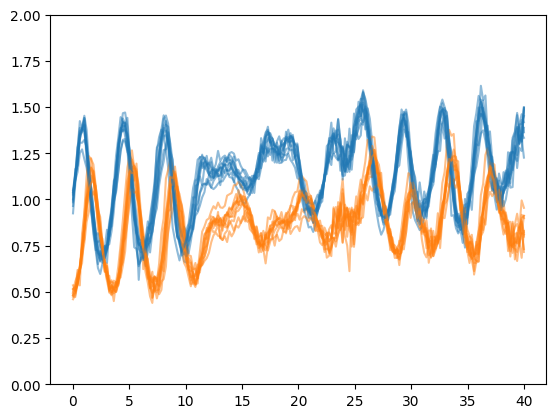

In [38]:
# Predicting the future

time_evals = node_metadata[4:4 + num_timeponts2]
predator_trace = samples[:, 4:4 + num_timeponts2]
prey_trace = samples[:, 4+num_timeponts2:]

for i in range(10):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)
    plt.ylim(0,2)